In [2]:
import tifffile as tf
import os
import numpy as np
from tqdm import tqdm
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import contextily as cx

In [ ]:
data_folder = os.environ["DATA_FOLDER"]
label_path = f"{data_folder}/local/label/"
aois = gpd.read_file(f"{data_folder}/metadata/aoi_extent.geojson")
all_label_paths = [label_path+path for path in os.listdir(label_path)]
raster_extents = gpd.read_file(f"{data_folder}/metadata/raster_extent.geojson")
events = pd.read_csv(f"{data_folder}/metadata/events.csv")

## Flood Events

In [55]:
print(f"Number of flood events: {raster_extents.event.nunique()}")
print(f"Number of flood subevents (flood events across different days): {raster_extents.subevent.nunique()}")

Number of flood events: 170
Number of flood subevents (flood events across different days): 668


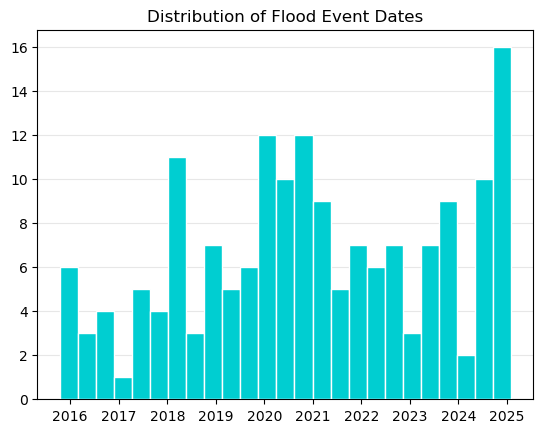

In [11]:
ax = raster_extents.sort_values("date").drop_duplicates("event", keep="first").hist("date", bins=25, edgecolor="white", color="darkturquoise", grid=False, zorder=100).flatten()[0]
ax.set_title("Distribution of Flood Event Dates");
ax.grid(alpha=0.3, axis="y", zorder=-100)

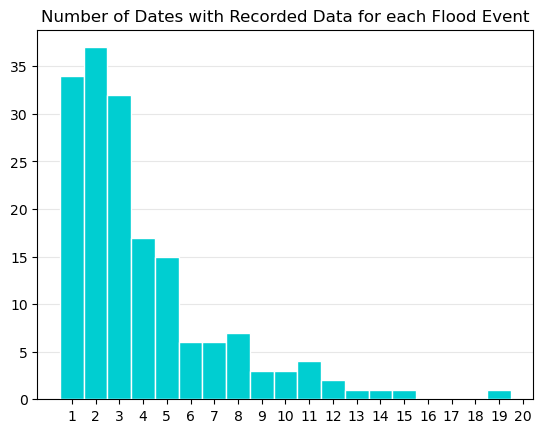

In [12]:
ax = raster_extents.groupby("event").count().hist("subevent", bins=np.arange(1, 21, 1), edgecolor="white", color="darkturquoise", grid=False, zorder=100, align="left").flatten()[0]
ax.set_title("Number of Dates with Recorded Data for each Flood Event");
ax.set_xticks(np.arange(1, 21, 1))
ax.grid(alpha=0.3, axis="y", zorder=-100)

In [274]:
events["Label"].value_counts(normalize=True)*100

Label
Good      76.470588
Medium    23.529412
Name: proportion, dtype: float64

In [172]:
print(f"Flood events in {events.Country.nunique()} different countries. \n")

print("Top countries:")
events.Country.value_counts().head(10)

Flood events in 51 different countries. 

Top countries:


Country
Italy             19
Germany           14
France            13
Australia         11
Greece             8
Spain              8
United Kingdom     7
Norway             5
Viet Nam           5
Ireland            5
Name: count, dtype: int64

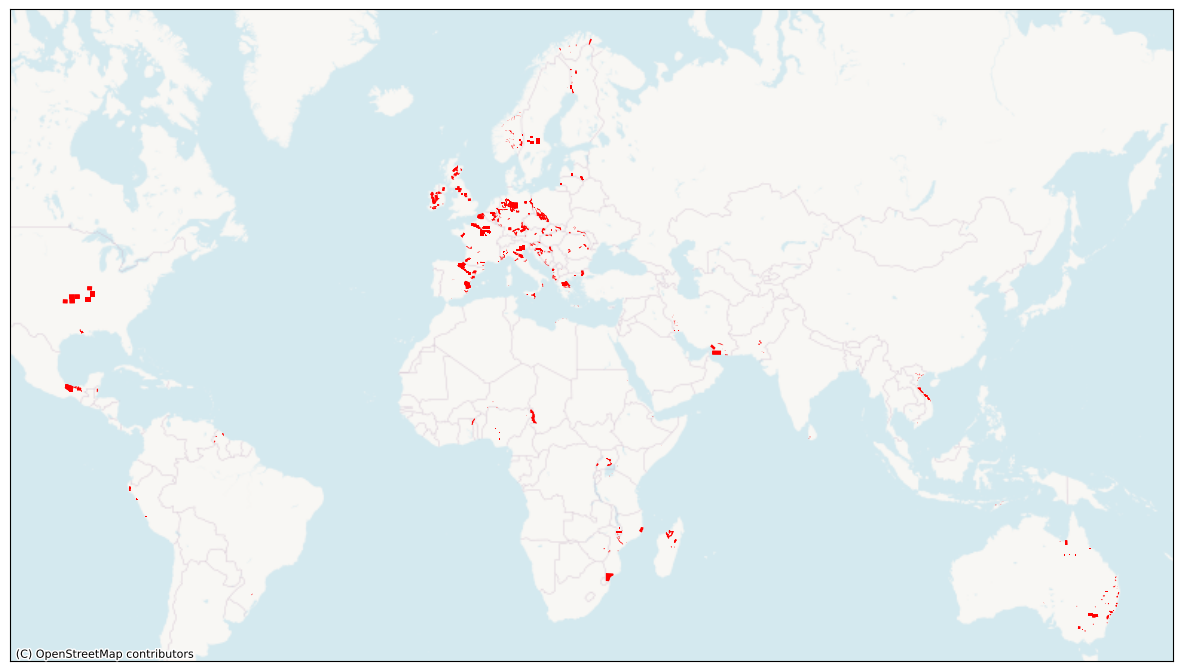

In [16]:
ax = aois.to_crs("EPSG:3857").plot(figsize=(15, 15), color="red")
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5)
ax.set_xticks([]), ax.set_yticks([]);

## Flood Dataset Patches

In [47]:
print(f"Number of patches: {len(all_label_paths):,}")

Number of patches: 295,917


In [44]:
contains_flood_water = 0
for path in tqdm(all_label_paths, leave=False):
    if np.isin(tf.imread(path), [2, 3]).any():
        contains_flood_water += 1

print(f"Percentage of patches containing flood water labels: {(contains_flood_water/len(all_label_paths))*100:.2f}%")

Percentage of patches containing flood water labels: 30.81%


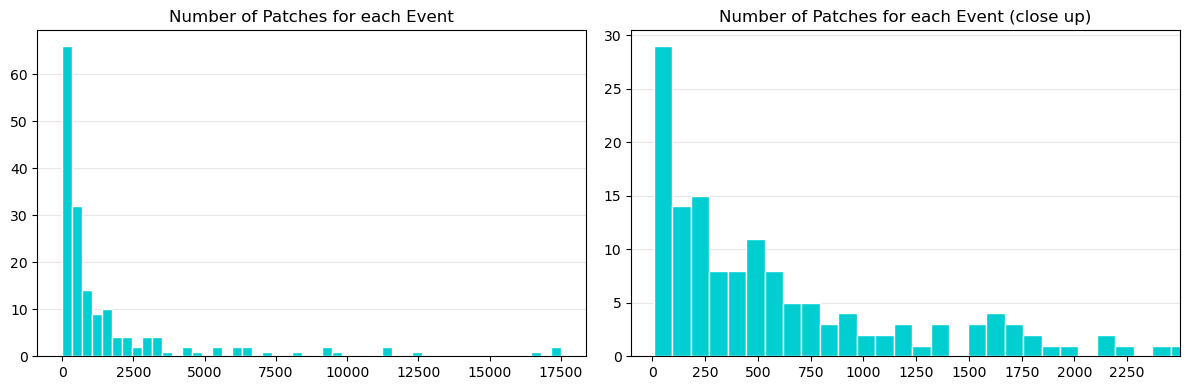

In [13]:
patch_dist_over_event = pd.Series([path.split("/")[-1].split("_")[0] for path in all_label_paths]).value_counts()
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
for index, bins in zip(range(2), [50, 200]):
    patch_dist_over_event.hist(bins=bins, edgecolor="white", color="darkturquoise", grid=False, zorder=100, ax=axes[index])
    axes[index].grid(alpha=0.3, axis="y", zorder=-100)
    axes[index].set_title("Number of Patches for each Event");
axes[1].set_xlim(-100, 2500)
axes[1].set_xticks(np.arange(0, 2500, 250))
axes[1].set_title("Number of Patches for each Event (close up)")
fig.tight_layout()

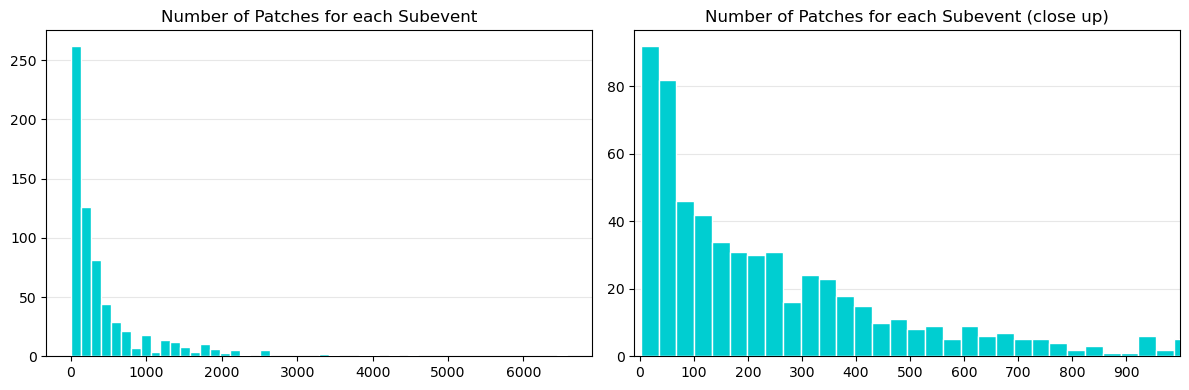

In [14]:
patch_dist_over_subevent = pd.Series(["_".join(path.split("/")[-1].split("_")[0:2]) for path in all_label_paths]).value_counts()
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
for index, bins in zip(range(2), [50, 200]):
    patch_dist_over_subevent.hist(bins=bins, edgecolor="white", color="darkturquoise", grid=False, zorder=100, ax=axes[index])
    axes[index].grid(alpha=0.3, axis="y", zorder=-100)
    axes[index].set_title("Number of Patches for each Subevent");
axes[1].set_xlim(-10, 1000)
axes[1].set_xticks(np.arange(0, 1000, 100))
axes[1].set_title("Number of Patches for each Subevent (close up)")
fig.tight_layout()